
=== PERBANDINGAN PERFORMA MODEL ===
               model  accuracy  precision    recall  f1_score
0        Naive Bayes  0.438053    0.53579  0.438053  0.464447
1  Naive Bayes + PSO  0.469027    0.56611  0.469027  0.499028

=== DISTRIBUSI SENTIMEN PUBLIK TERHADAP TONCOIN ===
  sentimen  jumlah  persentase
0  positif     636       56.43
1   netral     356       31.59
2  negatif     135       11.98


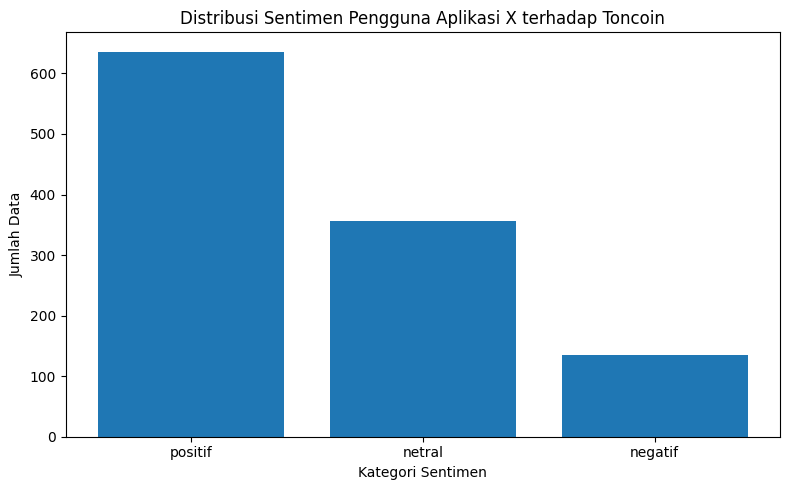

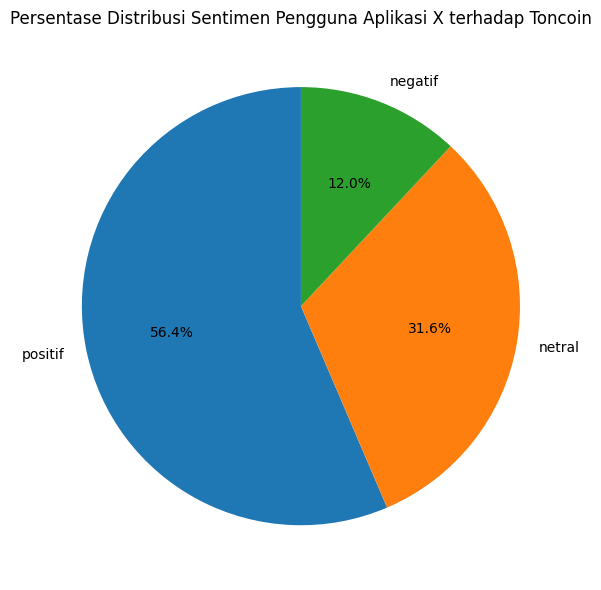

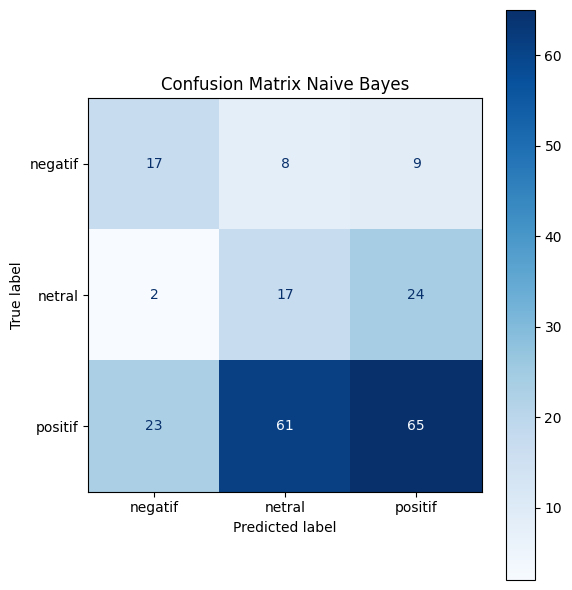

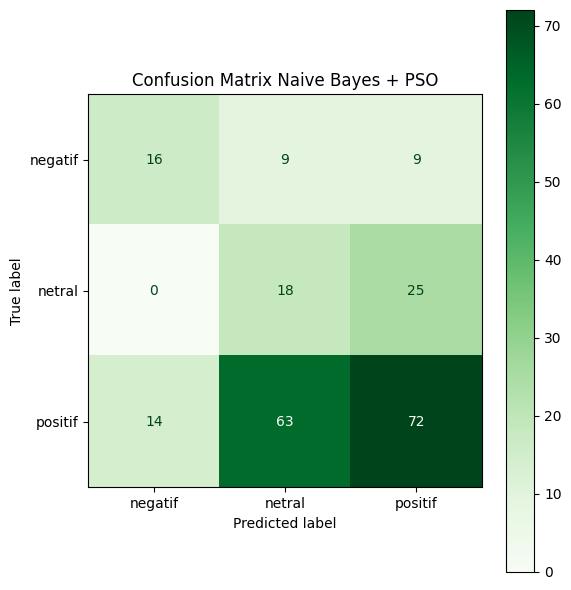

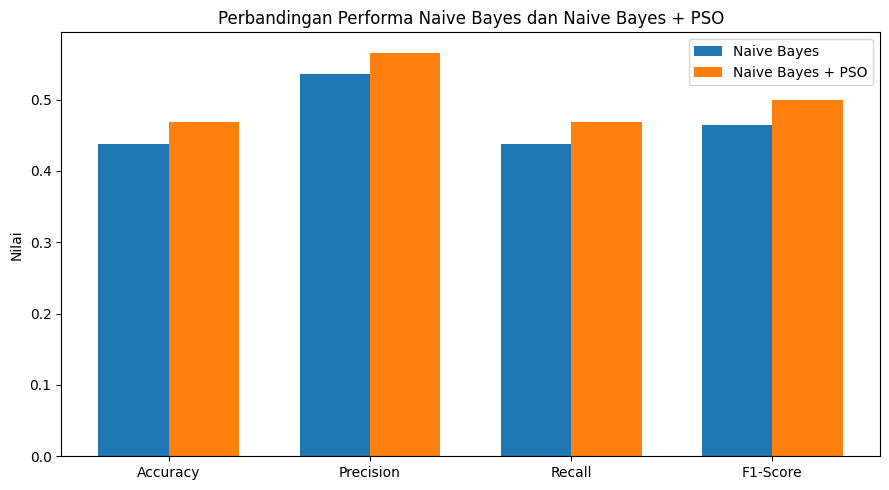


=== RINGKASAN DEPLOYMENT ===
   accuracy_naive_bayes  accuracy_naive_bayes_pso  peningkatan_akurasi_persen
0                0.4381                     0.469                        7.07

File output deployment:
1. deployment_distribusi_sentimen_toncoin.csv
2. deployment_perbandingan_performa_model.csv
3. deployment_confusion_matrix_naive_bayes.csv
4. deployment_confusion_matrix_naive_bayes_pso.csv
5. deployment_ringkasan_hasil.csv
6. grafik_distribusi_sentimen_bar.png
7. grafik_distribusi_sentimen_pie.png
8. deployment_confusion_matrix_naive_bayes.png
9. deployment_confusion_matrix_naive_bayes_pso.png
10. grafik_perbandingan_performa_model.png


In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# =========================================================
# 1. LOAD DATA DAN MODEL
# =========================================================
data = np.load("split_data.npz", allow_pickle=True)

X_test = data["X_test"]
y_test = data["y_test"]
X_train = data["X_train"]
y_train = data["y_train"]

model_nb = joblib.load("model_naive_bayes.pkl")
model_nb_pso = joblib.load("model_naive_bayes_pso.pkl")

# =========================================================
# 2. PREDIKSI DATA UJI
# =========================================================
y_pred_nb = model_nb.predict(X_test)
y_pred_nb_pso = model_nb_pso.predict(X_test)

# =========================================================
# 3. HITUNG METRIK EVALUASI
# =========================================================
hasil_performa = pd.DataFrame([
    {
        "model": "Naive Bayes",
        "accuracy": accuracy_score(y_test, y_pred_nb),
        "precision": precision_score(y_test, y_pred_nb, average="weighted", zero_division=0),
        "recall": recall_score(y_test, y_pred_nb, average="weighted", zero_division=0),
        "f1_score": f1_score(y_test, y_pred_nb, average="weighted", zero_division=0)
    },
    {
        "model": "Naive Bayes + PSO",
        "accuracy": accuracy_score(y_test, y_pred_nb_pso),
        "precision": precision_score(y_test, y_pred_nb_pso, average="weighted", zero_division=0),
        "recall": recall_score(y_test, y_pred_nb_pso, average="weighted", zero_division=0),
        "f1_score": f1_score(y_test, y_pred_nb_pso, average="weighted", zero_division=0)
    }
])

print("\n=== PERBANDINGAN PERFORMA MODEL ===")
print(hasil_performa)

# simpan hasil performa
hasil_performa.to_csv("deployment_perbandingan_performa_model.csv", index=False)

# =========================================================
# 4. DISTRIBUSI SENTIMEN
#    Menggunakan model terbaik: Naive Bayes + PSO
#    Prediksi dilakukan pada seluruh data agar distribusi
#    sentimen publik lebih representatif
# =========================================================
X_all = np.vstack([X_train, X_test])
y_all_pred = model_nb_pso.predict(X_all)

distribusi_sentimen = pd.DataFrame(y_all_pred, columns=["sentimen"])
distribusi_sentimen = distribusi_sentimen["sentimen"].value_counts().reset_index()
distribusi_sentimen.columns = ["sentimen", "jumlah"]
distribusi_sentimen["persentase"] = (
    distribusi_sentimen["jumlah"] / distribusi_sentimen["jumlah"].sum() * 100
).round(2)

print("\n=== DISTRIBUSI SENTIMEN PUBLIK TERHADAP TONCOIN ===")
print(distribusi_sentimen)

# simpan distribusi sentimen
distribusi_sentimen.to_csv("deployment_distribusi_sentimen_toncoin.csv", index=False)

# =========================================================
# 5. GRAFIK DISTRIBUSI SENTIMEN
# =========================================================
plt.figure(figsize=(8, 5))
plt.bar(distribusi_sentimen["sentimen"], distribusi_sentimen["jumlah"])
plt.title("Distribusi Sentimen Pengguna Aplikasi X terhadap Toncoin")
plt.xlabel("Kategori Sentimen")
plt.ylabel("Jumlah Data")
plt.tight_layout()
plt.savefig("grafik_distribusi_sentimen_bar.png", dpi=300)
plt.show()

plt.figure(figsize=(6, 6))
plt.pie(
    distribusi_sentimen["jumlah"],
    labels=distribusi_sentimen["sentimen"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Persentase Distribusi Sentimen Pengguna Aplikasi X terhadap Toncoin")
plt.tight_layout()
plt.savefig("grafik_distribusi_sentimen_pie.png", dpi=300)
plt.show()

# =========================================================
# 6. VISUALISASI CONFUSION MATRIX
# =========================================================
labels = np.unique(y_test)

cm_nb = confusion_matrix(y_test, y_pred_nb, labels=labels)
cm_nb_pso = confusion_matrix(y_test, y_pred_nb_pso, labels=labels)

# Confusion Matrix Naive Bayes
fig, ax = plt.subplots(figsize=(6, 6))
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=labels)
disp_nb.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix Naive Bayes")
plt.tight_layout()
plt.savefig("deployment_confusion_matrix_naive_bayes.png", dpi=300)
plt.show()

# Confusion Matrix Naive Bayes + PSO
fig, ax = plt.subplots(figsize=(6, 6))
disp_nb_pso = ConfusionMatrixDisplay(confusion_matrix=cm_nb_pso, display_labels=labels)
disp_nb_pso.plot(ax=ax, cmap="Greens", values_format="d")
plt.title("Confusion Matrix Naive Bayes + PSO")
plt.tight_layout()
plt.savefig("deployment_confusion_matrix_naive_bayes_pso.png", dpi=300)
plt.show()

# simpan confusion matrix ke csv
pd.DataFrame(cm_nb, index=labels, columns=labels).to_csv(
    "deployment_confusion_matrix_naive_bayes.csv"
)
pd.DataFrame(cm_nb_pso, index=labels, columns=labels).to_csv(
    "deployment_confusion_matrix_naive_bayes_pso.csv"
)

# =========================================================
# 7. GRAFIK PERBANDINGAN PERFORMA MODEL
# =========================================================
metrik = ["accuracy", "precision", "recall", "f1_score"]

x = np.arange(len(metrik))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(
    x - width/2,
    hasil_performa.loc[0, metrik],
    width,
    label="Naive Bayes"
)
plt.bar(
    x + width/2,
    hasil_performa.loc[1, metrik],
    width,
    label="Naive Bayes + PSO"
)

plt.xticks(x, ["Accuracy", "Precision", "Recall", "F1-Score"])
plt.ylabel("Nilai")
plt.title("Perbandingan Performa Naive Bayes dan Naive Bayes + PSO")
plt.legend()
plt.tight_layout()
plt.savefig("grafik_perbandingan_performa_model.png", dpi=300)
plt.show()

# =========================================================
# 8. HITUNG PERSENTASE PENINGKATAN
# =========================================================
nb_acc = hasil_performa.loc[0, "accuracy"]
nb_pso_acc = hasil_performa.loc[1, "accuracy"]

peningkatan_akurasi = ((nb_pso_acc - nb_acc) / nb_acc) * 100

ringkasan_deployment = pd.DataFrame([{
    "accuracy_naive_bayes": round(nb_acc, 4),
    "accuracy_naive_bayes_pso": round(nb_pso_acc, 4),
    "peningkatan_akurasi_persen": round(peningkatan_akurasi, 2)
}])

print("\n=== RINGKASAN DEPLOYMENT ===")
print(ringkasan_deployment)

ringkasan_deployment.to_csv("deployment_ringkasan_hasil.csv", index=False)

# =========================================================
# 9. INFORMASI FILE OUTPUT
# =========================================================
print("\nFile output deployment:")
print("1. deployment_distribusi_sentimen_toncoin.csv")
print("2. deployment_perbandingan_performa_model.csv")
print("3. deployment_confusion_matrix_naive_bayes.csv")
print("4. deployment_confusion_matrix_naive_bayes_pso.csv")
print("5. deployment_ringkasan_hasil.csv")
print("6. grafik_distribusi_sentimen_bar.png")
print("7. grafik_distribusi_sentimen_pie.png")
print("8. deployment_confusion_matrix_naive_bayes.png")
print("9. deployment_confusion_matrix_naive_bayes_pso.png")
print("10. grafik_perbandingan_performa_model.png")